                 Modelling 
This  will involve training a xgboost algorithm that will predict whether a customer will churn or not. First, we will standardize the feature engineered data, remove data imbalance by leveraging smote technique , fitting the data, hyperparameter tuning, prediction and shap analysis to gauge the imporatnce of features used in training the model              

In [ ]:
#importing prerequisites
import pandas as pd 
import numpy as np 
from  sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from xgboost import XGBClassifier 
from sklearn.metrics import classification_report, f1_score,confusion_matrix, ConfusionMatrixDisplay
import optuna
from imblearn.over_sampling import SMOTE

In [ ]:
#importing our dataset
df = pd.read_csv(r'./prprocessed/Banc_ChurnersProcessed.csv')
df.head()
df =df.drop(columns='Unnamed: 0', axis=1)

In [25]:
df['Attrition_Flag'].value_counts()

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

                         Feature selection


In [4]:
x = df.drop(columns=['Attrition_Flag'], axis=1)
y = df['Attrition_Flag']

Here will divide our dataset into two subsets i.e training set that will reprsent 80% of  the dataset for training model  and testing set 20%t to evaluate its performanceon unseen data.  

i set stratify= meaning  that i'm maintaining the ratio of churners and existing customers at 1:1 even if the churners are the minority class.This prevents the model from ignoring churners between evaluation.

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

                      Feature Scaling 
This is a method of transforming numerical features to a similar, consistent scale typically between 0 and 1  which makes it suitable for modelling 

We will use standard scaler  which normalizes data, scale features  with high numerical range like Tranaction_Amount and Transaction counts into smaller ranges to avoid drowning features with low range values like Depedence etc thus ensuring a balanced, unbiased model training.

Scaling only x_train and x_test features to avoid data leaks in the model.

In [6]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

                  Imbalanced Data 
Taking attrition flag into account, this dataset is higly imbalanced with existing customers having 8500 entries and attrited customers = 2700 . We will use smote to balance this data by creating new synthetic churners thus our model will not only learn patterns in majority class(Existing customers) but also minority ones (attrited customers) in our dataset.

In [ ]:
#balncing our data
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train_scaled, y_train)


                     Hyperparameter optimization 
This is the process of finding the best weights/parameters for our model to improve performance  in accuracy, save time and compute resorces.

i chose Optuna is  since it uses bayesian optimization to to learn from past trials, terminates trials early if they show no promise for better results and it treats searching for the best parameters as a dynamic optimization problem thus maximizing fi-score.

Below is a function thats implement it and feeds those resultant to our xgboost model which is a tree based algorithm that i will use due to high speed, performance  and scalability.

In [ ]:
#hyperparameter tuning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth' : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42
    }
    model = XGBClassifier(**params)
    model.fit(x_resampled, y_resampled)
    y_pred = model.predict(x_test_scaled)
    return f1_score(y_test, y_pred)
#
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-02-22 14:02:52,220] A new study created in memory with name: no-name-864696f0-e6ec-4c4d-bc35-90ce811ebb17
[I 2026-02-22 14:02:57,493] Trial 0 finished with value: 0.8936825885978429 and parameters: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.022967994822264762, 'gamma': 1.7271754454359245, 'subsample': 0.7450704278434002, 'colsample_bytree': 0.7155671007096723}. Best is trial 0 with value: 0.8936825885978429.
[I 2026-02-22 14:02:59,426] Trial 1 finished with value: 0.9073482428115016 and parameters: {'n_estimators': 331, 'max_depth': 5, 'learning_rate': 0.08719507579808397, 'gamma': 0.06420330563624493, 'subsample': 0.6517960347243771, 'colsample_bytree': 0.6497794001985326}. Best is trial 1 with value: 0.9073482428115016.
[I 2026-02-22 14:03:00,915] Trial 2 finished with value: 0.875 and parameters: {'n_estimators': 152, 'max_depth': 10, 'learning_rate': 0.07078440470418697, 'gamma': 3.497771230563404, 'subsample': 0.9916222532078794, 'colsample_bytree': 0.8452094

Now we will take th resultant best parametrs derived from optuna and use them to train our model and obtain probabilities of predictions of churned or existing customers.

In [ ]:
best_model = XGBClassifier(**study.best_params)
best_model.fit(x_resampled, y_resampled)
#getting probabilities of our predictions
y_probs=best_model.predict_proba(x_test_scaled)[:, 1]



Below is a dataframe that shows bank customers and their probabilities of churning and also their positon in categorisation of whether thay are at high risk of leaving, low or critical.

In [ ]:
final_df = x_test.copy()
final_df['Actual_Churn'] = y_test 
final_df['Churn_Probability'] = y_probs 
top_risks = final_df.sort_values(by='Churn_Probability', ascending=False)
def categorize_customer(probability):
    if probability > 0.9: return 'Critical level'
    if probability > 0.75: return 'High risk'
    if probability > 0.5: return 'Medium risk'
    else :return  'Low risk'
top_risks['Risk_level'] = top_risks['Churn_Probability'].apply(categorize_customer)
top_risks.head()

,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Actual_Churn,Churn_Probability
7253,57,3,3,0,45,1,4,2,1759.0,186,...,0.522,0.106,False,True,False,False,False,False,1,0.999988
5925,55,2,3,0,50,2,6,3,1720.0,0,...,0.440,0.000,False,False,False,False,False,False,1,0.999987
4872,40,3,1,3,34,1,3,4,29715.0,0,...,0.345,0.000,True,True,False,False,False,False,1,0.999982
6244,45,2,2,0,33,1,3,3,1833.0,0,...,0.292,0.000,False,False,True,False,False,False,1,0.999977
8186,44,1,1,0,36,2,3,3,1895.0,0,...,0.429,0.000,False,False,True,False,False,False,1,0.999967


Below is the confusion matrix that breaks down how  a model performed by comparing its predictions against true values i.e those predictions that were true positives, true negatives, false positives and false negatives.

Text(0.5, 1.0, 'Confusion Matrix')

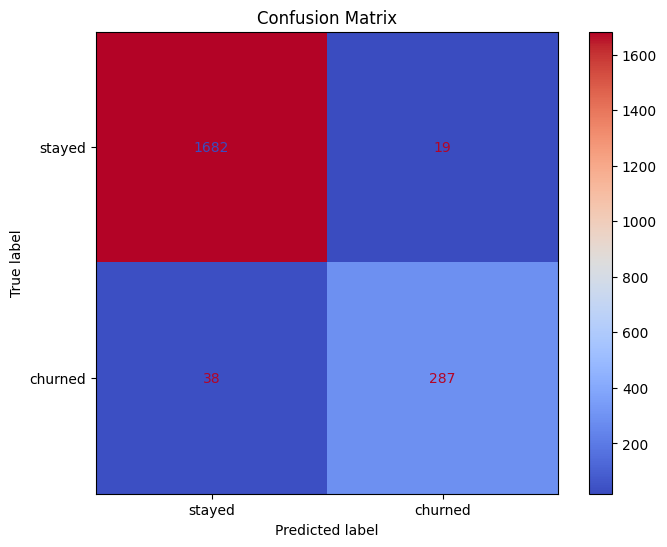

In [11]:
import matplotlib.pyplot as plt
y_pred = best_model.predict(x_test_scaled)

fig, ax =  plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix =cm, display_labels =['stayed', 'churned'])
disp.plot(cmap='coolwarm', ax=ax, values_format='d')
plt.title('Confusion Matrix')
 

             Observations

The model correctly predicted 1682 customers will stay (True positives),

The model predicted 19 customers will stay but they churned (False positives),

The model predicted 38 customers will churn but they stayed (False negative)

The model correctly predicted 287 cutomers will churn and they left the firm (Tue negatives)
              
              conclusions 

This model is quite aggressive since it predicted 38 customers will churn yet they stayed comapred to 19 that it predicted will stay but they churned. This is better in a financial institution since the loss of a customer may outweigh the costs of wrongly flagging a customer that might stay.

                    Feature importance


Below is a barchart that will show the top 10 faetures taht were the drivers of churning given their importance score.

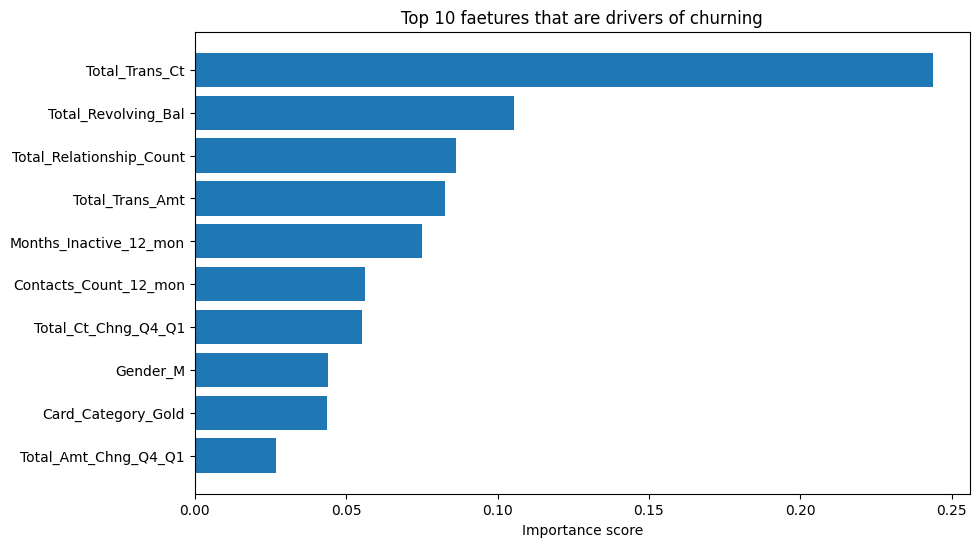

In [12]:
importances = best_model.feature_importances_
feature_names = x.columns 
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title('Top 10 faetures that are drivers of churning')
plt.xlabel('Importance score')
plt.show()

from the barchart, Totaal_transaction-count is the largest driver of churning with importance score between 0.20-0.25 followed by Total_revolving_balance with a score of around 0.10 while Total_amount_change_q4_q1 is the leastdriver of churning with importance score of less than 0.05

                Shap analysis

This will tell us whichfeatures pushed a customer's probability to the top and the resultant plot not onlyshows feature importance but also direction i.e does low value on a feature make churn likely or not.

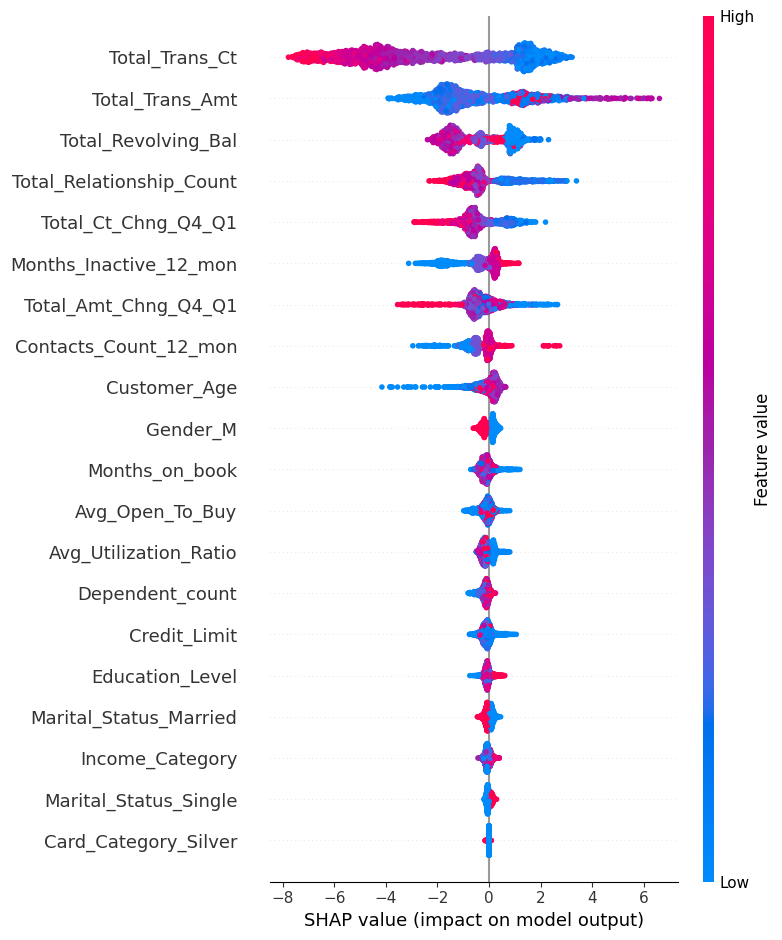

In [20]:
import shap 
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x.columns)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(x_test_scaled_df)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_scaled, feature_names=x.columns)

                   Waterfall plot 
This plot will show how an individual prediction was reached by breaking down the contribution of every feature. 

The read bars are features that increased the probability of churning while the blue bars are features that mitigate the probabilities of churning.

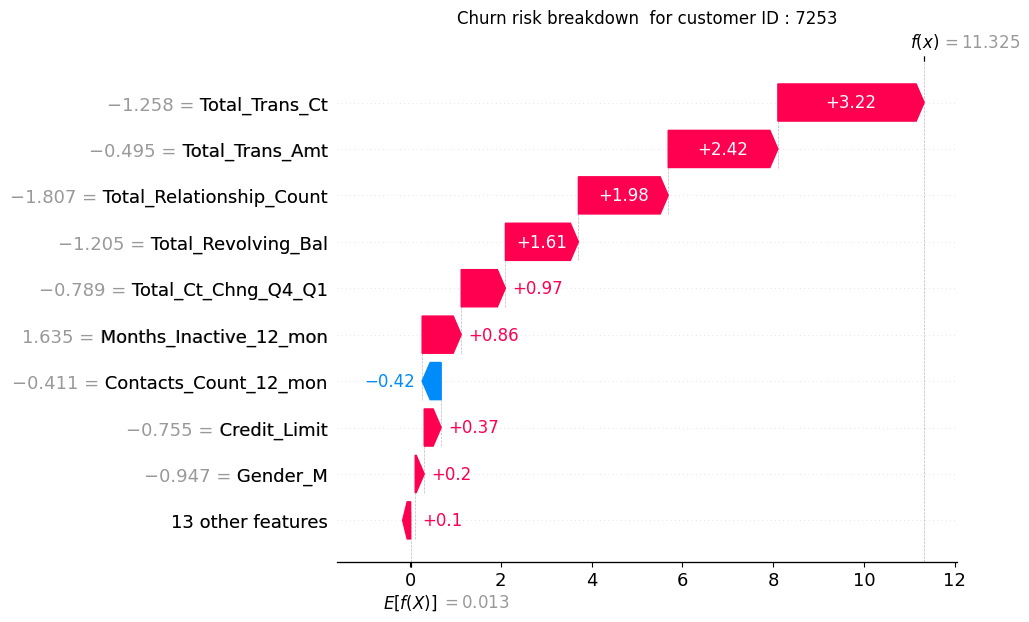

In [23]:
high_risk_idx = np.argmax(y_probs)
customer_id = x_test.index[high_risk_idx]
plt.title(f'Churn risk breakdown  for customer ID : {customer_id}')
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10)
plt.show()

                Observation
The average predictions of all customers is E[f(x)] = -0.023 thus the model starts from close to zero which is neutral state. 

The prediction for customer 7253 is (f(x)=11.325) which translates to 100% probability that the customer will churn.

The key drivers of churning are:

Total_Tran_Ct having a shap score of 3.22 means this customer's transaction count is lower than average.

Total_trans_amt having a score of 2.42 shows the customer is not only spending uing the card less frequently but also with less money. 

Total__relationship_count havin a score of 1.98 shows the customer had fewer products with the bank.

Total_Revolving_Bal has a score of 1.61 uggesting the customer has either moved his spending to another bank competitor or they had completely paid their debt.

Contacts_Count_12_mon having a score of -0.42 is the mitigating factor that lowering the churn risk meaning the customer has had fewer interctions with the bank i.e fewer complains.